<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/firstmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets torch torchvision torchaudio scikit-learn matplotlib seaborn --quiet


In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
dataset = load_dataset("imdb")
dataset["train"][0]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [4]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

encoded_dataset = dataset.map(tokenize, batched=True)
encoded_dataset = encoded_dataset.rename_column("label", "labels")
encoded_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True
)

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), dim=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    return {"accuracy": acc, "f1": f1}


In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"].shuffle(seed=42).select(range(5000)),  # smaller subset
    eval_dataset=encoded_dataset["test"].shuffle(seed=42).select(range(2000)),
    compute_metrics=compute_metrics
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: cmanan36 (cmanan36-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.432700,0.334628,0.872500,0.873575
2,0.281500,0.450731,0.872500,0.874816


TrainOutput(global_step=1250, training_loss=0.33298753967285155, metrics={'train_runtime': 679.4037, 'train_samples_per_second': 14.719, 'train_steps_per_second': 1.84, 'total_flos': 657777638400000.0, 'train_loss': 0.33298753967285155, 'epoch': 2.0})

In [10]:
eval_results = trainer.evaluate()
print("Evaluation:", eval_results)


Evaluation: {'eval_loss': 0.33462807536125183, 'eval_accuracy': 0.8725, 'eval_f1': 0.873574615765989, 'eval_runtime': 13.8027, 'eval_samples_per_second': 144.899, 'eval_steps_per_second': 18.112, 'epoch': 2.0}


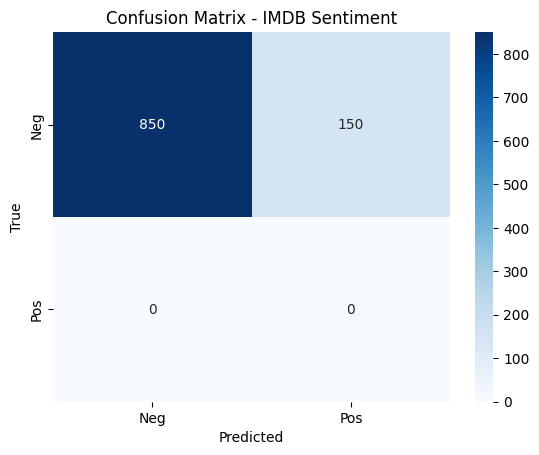

              precision    recall  f1-score   support

    Negative       1.00      0.85      0.92      1000
    Positive       0.00      0.00      0.00         0

    accuracy                           0.85      1000
   macro avg       0.50      0.42      0.46      1000
weighted avg       1.00      0.85      0.92      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
import numpy as np

preds_output = trainer.predict(encoded_dataset["test"].select(range(1000)))
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
plt.title("Confusion Matrix - IMDB Sentiment")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))


In [13]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    # Move input tensors to the same device as the model
    device = model.device
    inputs = {name: tensor.to(device) for name, tensor in inputs.items()}
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()
    return "Positive 😊" if prediction == 1 else "Negative 😞"

print(predict_sentiment("The movie was fantastic and emotional!"))
print(predict_sentiment("I didn’t like the movie at all, it was boring."))

Positive 😊
Negative 😞


In [15]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    # Move input tensors to the same device as the model
    device = model.device
    inputs = {name: tensor.to(device) for name, tensor in inputs.items()}
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()
    return "Positive 😊" if prediction == 1 else "Negative 😞"

print(predict_sentiment("The movie was fantastic and emotional!"))
print(predict_sentiment("I didn’t like the movie at all, it was boring."))

Positive 😊
Negative 😞


In [17]:
from huggingface_hub import notebook_login

notebook_login()  # Log in with your Hugging Face account

model.push_to_hub("manan-bert-imdb-sentiment")
tokenizer.push_to_hub("manan-bert-imdb-sentiment")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rgqw1u_/model.safetensors:   0%|          | 14.2kB /  438MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/manan36chauhan/manan-bert-imdb-sentiment/commit/b6869afc2791a4495a72f4739f816f5ca72929a6', commit_message='Upload tokenizer', commit_description='', oid='b6869afc2791a4495a72f4739f816f5ca72929a6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/manan36chauhan/manan-bert-imdb-sentiment', endpoint='https://huggingface.co', repo_type='model', repo_id='manan36chauhan/manan-bert-imdb-sentiment'), pr_revision=None, pr_num=None)

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "manan36chauhan/manan-bert-imdb-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

inputs = tokenizer("It was not bad !", return_tensors="pt")
outputs = model(**inputs)
pred = torch.argmax(outputs.logits).item()
print("Positive" if pred == 1 else "Negative")

Positive
